<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Regress%C3%A3o_Log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Regressão Logística

A regressão logística é uma técnica de aprendizado de máquina utilizada para classificação. Estima a probabilidade de uma instância perterncer a uma classe.

Assim como na regressão linear a equação que rege o modelo de regressão logística é a equação da reta. Ou seja:


$$
y = wx + b
$$

Essa saída pode assumir qualquer valor real, como $-10$, $0.3$, $7.8$ ou $100$, mas para a classificação binária, por exemplo, a saída deveria estar entre **0 e 1** e precisa ser interpretada como uma **probabilidade**.

A regressão logística resolve isso aplicando a **função sigmoide** sobre a combinação linear dos dados.

## Função sigmoide

A função sigmoide é definida por:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ela transforma qualquer valor real em um valor entre 0 e 1.

- Se $z$ for muito positivo, $\sigma(z)$ se aproxima de 1.
- Se $z$ for muito negativo, $\sigma(z)$ se aproxima de 0.
- Se $z = 0$, então $\sigma(z) = 0.5$.

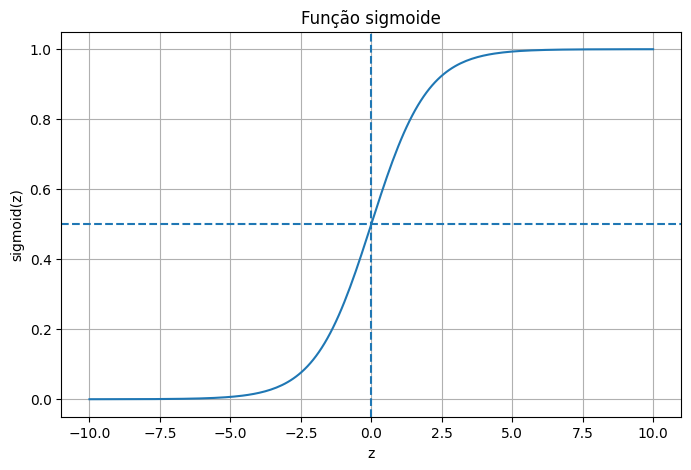

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Função sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, y)
plt.axhline(0.5, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Função sigmoide')
plt.grid(True)
plt.show()

## Regressão Logística com uma variável de entrada

Calcula-se z, com base na equação de regressão.

$$
z = wx + b
$$

Calcula-se a saída do modelo com a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-(wx+b)}}
$$

Como $\hat{y}$ está entre 0 e 1, pode-se interpretá-lo como uma probabilidade:

$$
\hat{y} = P(y=1|x)
$$

Ou seja, o modelo estima a probabilidade de o exemplo pertencer à classe 1.

Depois que o modelo calcula uma probabilidade, define-se um limiar para decidir a classe.

Normalmente o limiar é definido em 0.5:

$$
\text{classe} =
\begin{cases}
1, & \text{se } \hat{y} \geq 0.5 \\
0, & \text{se } \hat{y} < 0.5
\end{cases}
$$

Esse limiar pode ser alterado dependendo do problema.

## Função de Custo

Na regressão linear é comum usar o erro quadrático médio. Na regressão logística a função de custo utilizada é a **entropia cruzada binária**, também chamada de **log loss**.

A função de custo é definida da seguinte maneira:

$$
J(w,b) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Essa função penaliza fortemente previsões muito confiantes e erradas.

Assim como na regressão linear, o processo de treinamento na regressão logística consiste em ajustar $w$ e $b$ para reduzir a função de custo.

Para uma variável de entrada, as derivadas podem ser escritas como:

$$
dw = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)x_i
$$

$$
db = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)
$$

A atualização dos parâmetros é:

$$
w = w - \alpha dw
$$

$$
b = b - \alpha db
$$

Onde $\alpha$ é a taxa de aprendizagem.

# Exemplo

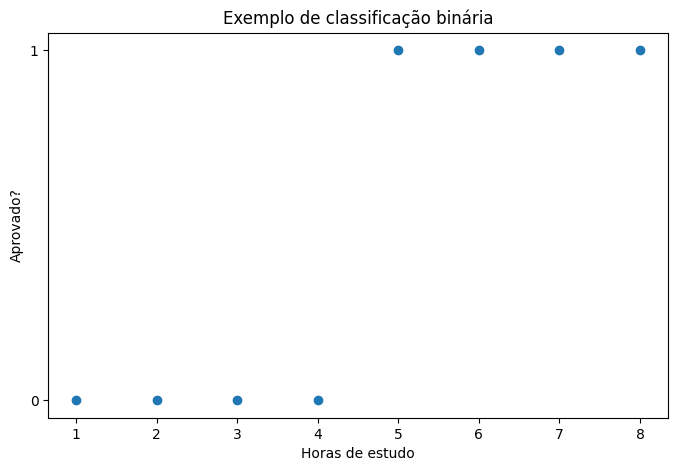

In [4]:
# Exemplo simples: horas de estudo x aprovação
# 0 = não aprovado, 1 = aprovado

horas = np.array([1, 2, 3, 4, 5, 6, 7, 8])
aprovado = np.array([0, 0, 0, 0, 1, 1, 1, 1])

plt.figure(figsize=(8, 5))
plt.scatter(horas, aprovado)
plt.xlabel('Horas de estudo')
plt.ylabel('Aprovado?')
plt.title('Exemplo de classificação binária')
plt.yticks([0, 1])
plt.grid(True)
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression


X = horas.reshape(-1, 1).astype(float)
y = aprovado.reshape(-1, 1).astype(float)

modelo = LogisticRegression()
modelo.fit(X, y)

pred = modelo.predict(X)
prob = modelo.predict_proba(X)

print('Coeficiente w:', modelo.coef_)
print('Intercepto b:', modelo.intercept_)

Coeficiente w: [[1.16979937]]
Intercepto b: [-5.26410791]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Fazendo predições

In [8]:
modelo.predict([[2]])

array([0.])

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.